In [124]:
import numpy as np
import matplotlib.pyplot as plt

import csv

def getSamples(tList, fct, f, a = 1, phi = 0):
    return [fct(t, f, a, phi) for t in tList]

def pltStemWrapper(timeAxis, fct, f, a = 1, phi = 0):
    plt.stem(timeAxis, getSamples(timeAxis, fct, f, a, phi))
    
def pltPlotWrapper(timeAxis, fct, f, a = 1, phi = 0):
    plt.plot(timeAxis, getSamples(timeAxis, fct, f, a, phi))


In [125]:
def signalSin(t, f, a, phi):
    return a*np.sin(2*np.pi*f*t + phi)


In [126]:
class Axis:
    def __init__(self, time_of_view = 1, sampling_rate = 441e2):
        self.time_of_view = time_of_view                          # seconds
        
        self.sampling_rate = sampling_rate                        # Hertz
        self.sampling_period = 1./self.sampling_rate              # seconds
        self.n_samples = self.time_of_view/self.sampling_period   # no unit of measure 
        
        self.time = np.linspace (0, self.time_of_view, int(self.n_samples)) # + 1), dtype = 'complex_')  # seconds
        

In [127]:
def rectangular_window(N):
    return np.ones((N))

def hanning(N):
    window = np.zeros(N)
    for n in range(len(window)):
        window[n] = 0.5 * (1 - np.cos(2 * np.pi * n/N))
    return window


In [134]:
# ex 1
N1 = 2000
fs1 = 200
time_of_view1 = N/fs

time1 = Axis(time_of_view1, fs1).time


signal1 = np.asarray(getSamples(time1, signalSin, 100))

w1_rectangular = rectangular_window(200)
signal1_w1_rectangular = signal1 * w1_rectangular               #  product of the two vectors

w1_hanning = hanning(200)
signal1_w1_hanning = signal1 * w1_hanning


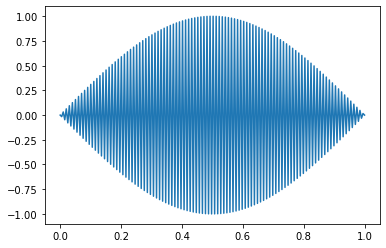

In [135]:
plt.plot(time1, signal1_w1_rectangular)
plt.show()


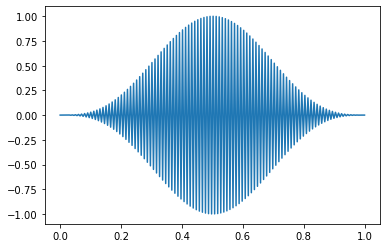

In [136]:
plt.plot(time1, signal1_w1_hanning)
plt.show()


In [131]:
# ex 2
class Train:
    def __init__(self, id, date_time, count):
        self.id = id
        self.date_time = date_time
        self.count = count
        
    def __repr__(self):
        return "(id = {0}) | date_time = {1} | count = {2})".format(self.id, self.date_time, self.count)
      

In [132]:
time_of_view2 = 24 * 7   # 1 week
fs2 = 1 # 1 sample per h
N2 = fs2 * time_of_view2

time_of_view2 = time_of_view2 // 7 * 3
N2 = N2 // 7 * 3 

trains = None
with open('Train.csv', newline='') as f:
    reader = csv.reader(f)
    x = list(reader)[1:]
    x = x[:N2]
    
    trains = [Train(int(elem[0]), elem[1], int(elem[2])) for elem in x]
    trains = np.asarray(trains)

signal2 = [elem.count for elem in trains]
signal2 = np.asarray(signal)
print(signal2)


[8 2 6 2 2 2 2 2 6 2 2 6 4 2 6 2 2 2 2 2 2 6 2 2 4 6 2 4 2 2 2 2 2 4 2 2 8
 6 6 6 2 4 4 4 2 2 4 6 6 2 2 2 2 2 4 2 2 2 2 2 2 2 2 4 2 2 4 2 4 2 2 4]


In [139]:
for dim in [5, 9, 13, 17]:
    w = hanning(dim)
    conv = np.convolve(signal2, np.ones(dim), 'valid')         # np.ones(w) ?? 
    print(conv)


[20. 14. 14. 10. 14. 14. 14. 18. 20. 16. 20. 20. 16. 14. 14. 10. 10. 14.
 14. 14. 16. 20. 16. 18. 18. 16. 12. 12. 10. 12. 12. 12. 18. 22. 24. 28.
 28. 24. 22. 20. 16. 16. 16. 18. 20. 20. 20. 18. 14. 10. 12. 12. 12. 12.
 12. 10. 10. 10. 10. 12. 12. 12. 14. 14. 14. 14. 14. 14.]
[32. 26. 26. 26. 28. 28. 32. 32. 32. 28. 28. 28. 24. 26. 26. 22. 24. 28.
 28. 30. 30. 30. 26. 26. 26. 26. 22. 22. 26. 30. 34. 38. 38. 40. 40. 42.
 42. 36. 34. 34. 34. 34. 32. 30. 28. 28. 30. 28. 24. 20. 20. 20. 20. 20.
 20. 20. 20. 20. 22. 22. 24. 24. 24. 26.]
[46. 40. 44. 40. 40. 40. 40. 40. 40. 40. 40. 40. 38. 40. 40. 38. 38. 38.
 38. 38. 38. 40. 36. 36. 42. 44. 44. 48. 46. 48. 50. 52. 52. 52. 52. 56.
 60. 54. 50. 46. 42. 42. 42. 40. 38. 38. 38. 36. 32. 28. 28. 30. 30. 30.
 32. 30. 32. 32. 32. 34.]
[58. 52. 52. 48. 48. 52. 52. 52. 54. 54. 54. 56. 52. 50. 50. 46. 46. 48.
 48. 48. 54. 58. 58. 62. 62. 62. 60. 62. 60. 60. 62. 66. 70. 70. 68. 68.
 68. 62. 60. 56. 52. 52. 50. 48. 46. 46. 46. 46. 42. 38. 40. 40. 42. 42